### Setup

In [76]:
import numpy as np
import json
import csv
import os
import torch

TRAIN_CSV = os.path.join("train_data\\train", "train.csv")

def box_iou_np(boxes1, boxes2):
    """
    Calculates Intersection over Union (IoU) between two sets of boxes.
    boxes1: numpy array of shape (N, 4) in format [x1, y1, x2, y2]
    boxes2: numpy array of shape (M, 4) in format [x1, y1, x2, y2]
    Returns: numpy array of shape (N, M) containing IoU scores.
    """
    boxes1 = np.array(boxes1, dtype=np.float32)
    boxes2 = np.array(boxes2, dtype=np.float32)

    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)), dtype=np.float32)

    area1 = np.maximum(0, boxes1[:, 2] - boxes1[:, 0]) * np.maximum(0, boxes1[:, 3] - boxes1[:, 1])
    area2 = np.maximum(0, boxes2[:, 2] - boxes2[:, 0]) * np.maximum(0, boxes2[:, 3] - boxes2[:, 1])

    lt = np.maximum(boxes1[:, None, :2], boxes2[None, :, :2])  # top-left
    rb = np.minimum(boxes1[:, None, 2:], boxes2[None, :, 2:])  # bottom-right

    wh = np.maximum(0, rb - lt)
    inter = wh[:, :, 0] * wh[:, :, 1]

    union = area1[:, None] + area2[None, :] - inter
    return inter / np.maximum(union, 1e-6)


def evaluate_detection_np(pred_boxes, gt_boxes, iou_thr=0.5):
    """
    Evaluates one image using greedy one-to-one matching.

    IMPORTANT:
    pred_boxes must be sorted by confidence score (highest to lowest).

    Returns a dictionary with:
      tp, fp, fn, precision, recall, f1, f2
    """
    pred_boxes = np.array(pred_boxes, dtype=np.float32)
    gt_boxes = np.array(gt_boxes, dtype=np.float32)

    # Handle edge cases
    if len(pred_boxes) == 0 and len(gt_boxes) == 0:
        return {
            "tp": 0, "fp": 0, "fn": 0,
            "precision": 1.0, "recall": 1.0,
            "f1": 1.0, "f2": 1.0
        }

    if len(pred_boxes) == 0:
        fn = len(gt_boxes)
        return {
            "tp": 0, "fp": 0, "fn": fn,
            "precision": 0.0, "recall": 0.0,
            "f1": 0.0, "f2": 0.0
        }

    if len(gt_boxes) == 0:
        fp = len(pred_boxes)
        return {
            "tp": 0, "fp": fp, "fn": 0,
            "precision": 0.0, "recall": 0.0,
            "f1": 0.0, "f2": 0.0
        }

    ious = box_iou_np(pred_boxes, gt_boxes)
    gt_used = np.zeros(len(gt_boxes), dtype=bool)

    tp = 0
    fp = 0

    # Greedy matching
    for p in range(len(pred_boxes)):
        row = ious[p].copy()
        row[gt_used] = -1.0

        best_g = np.argmax(row)
        best_iou = row[best_g]

        if best_iou >= iou_thr:
            tp += 1
            gt_used[best_g] = True
        else:
            fp += 1

    fn = np.sum(~gt_used)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    if precision == 0 and recall == 0:
        f1 = 0.0
        f2 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)
        f2 = (1 + 2**2) * precision * recall / (2**2 * precision + recall)

    return {
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "f2": float(f2),
    }


def evaluate_train_baseline(train_csv_path, output=True, clean_fn = None, nms_thresh = 0.1, score_thresh = 0.7):
    with open(train_csv_path, "r", encoding="utf-8") as f:
        train_rows = list(csv.DictReader(f))

    total_tp = 0
    total_fp = 0
    total_fn = 0

    f1_scores = []
    f2_scores = []

    for row in train_rows:
        pred_boxes_list = json.loads(row["pred_boxes"])
        pred_scores_list = json.loads(row["pred_scores"])
        gt_boxes_list = json.loads(row["gt_boxes"])

        if clean_fn:
            pred_boxes_list, pred_scores_list = clean_fn(pred_boxes_list, pred_scores_list, nms_thresh, score_thresh)

        # Sort predicted boxes by score descending
        if len(pred_scores_list) > 0:
            paired = list(zip(pred_scores_list, pred_boxes_list))
            paired.sort(key=lambda x: x[0], reverse=True)
            pred_boxes_list = [box for score, box in paired]

        result = evaluate_detection_np(pred_boxes_list, gt_boxes_list, iou_thr=0.5)

        total_tp += result["tp"]
        total_fp += result["fp"]
        total_fn += result["fn"]

        f1_scores.append(result["f1"])
        f2_scores.append(result["f2"])

    # Global precision / recall / F1 / F2
    global_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    global_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0

    if global_precision == 0 and global_recall == 0:
        global_f1 = 0.0
        global_f2 = 0.0
    else:
        global_f1 = 2 * global_precision * global_recall / (global_precision + global_recall)
        global_f2 = (1 + 2**2) * global_precision * global_recall / (2**2 * global_precision + global_recall)

    # !!!! Here is the official score that will be used for ranking in the competition
    official_score = 0.4 * global_f2 + 0.6 * global_f1

    if output:
        print("-" * 50)
        print("TRAIN SET BASELINE RESULTS (Score threshold = 0.05)")
        print("-" * 50)
        print(f"Total True Positives (TP):   {total_tp}")
        print(f"Total False Positives (FP):  {total_fp}")
        print(f"Total False Negatives (FN):  {total_fn}")
        print(f"Global Precision:            {global_precision:.4f}")
        print(f"Global Recall:               {global_recall:.4f}")
        print(f"Global F1@0.5:               {global_f1:.4f}")
        print(f"Global F2@0.5:               {global_f2:.4f}")
        print(f"Mean image-level F1@0.5:     {np.mean(f1_scores):.4f}")
        print(f"Mean image-level F2@0.5:     {np.mean(f2_scores):.4f}")
        print("-" * 50)
        print("If your NMS / filtering algorithm is working, FP should usually go down.")

        print("-" * 50)
        print(f"Official score (for leaderboard):  {official_score:.4f}")
        print("-" * 50)

    return official_score

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def visualize_boxes(image_path, boxes, ax, scores=None, color='red', title="Bounding Boxes"):
    """
    Reads an image and overlays a list of bounding boxes.
    
    Parameters:
    - image_path (str): Path to the image file.
    - boxes (list or array): List of bounding boxes in [x_min, y_min, x_max, y_max] format.
    - scores (list or array, optional): Confidence scores to display above each box.
    - color (str, optional): Color of the bounding boxes (e.g., 'red', 'green', 'blue').
    - title (str, optional): Title for the plot.
    """
    try:
        # Open the image
        img = Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return
    
    # Create figure and axes
    ax.imshow(img)
    ax.set_title(title)
    
    # Loop over the boxes and add them to the plot
    for i, box in enumerate(boxes):
        x_min, y_min, x_max, y_max = box
        width = x_max - x_min
        height = y_max - y_min
        
        # Create a Rectangle patch
        rect = patches.Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        
        # If scores are provided, add them as text slightly above the box
        if scores is not None and i < len(scores):
            score_text = f"{scores[i]:.2f}"
            ax.text(x_min, y_min - 5, score_text, color='white', fontsize=10, fontweight='bold',
                    bbox=dict(facecolor=color, alpha=0.7, pad=2, edgecolor='none'))
            
    # Remove axes ticks for a cleaner look
    ax.axis('off')

### Task

In [2]:
import pandas as pd
train_df = pd.read_csv(TRAIN_CSV)
train_df.head(5)

,filename,pred_boxes,pred_scores,gt_boxes
0,FudanPed00001.png,"[[419.68597412109375, 170.06802368164062, 536....","[0.9997385144233704, 0.9995905756950378]","[[159.0, 181.0, 301.0, 430.0], [419.0, 170.0, ..."
1,FudanPed00002.png,"[[67.23969268798828, 91.85848999023438, 188.70...","[0.9994507431983948, 0.9952310919761658, 0.276...","[[67.0, 92.0, 190.0, 379.0]]"
2,FudanPed00003.png,"[[285.0282287597656, 129.271484375, 443.854888...","[0.9997422099113464, 0.6000857353210449, 0.310...","[[292.0, 134.0, 446.0, 420.0]]"
3,FudanPed00005.png,"[[180.94015502929688, 54.6724853515625, 318.92...","[0.9991474151611328, 0.9936768412590027, 0.931...","[[187.0, 58.0, 319.0, 335.0], [1.0, 52.0, 39.0..."
4,FudanPed00006.png,"[[204.8242645263672, 95.5763168334961, 349.535...","[0.9995357990264893, 0.9956884980201721, 0.981...","[[207.0, 107.0, 345.0, 384.0], [1.0, 107.0, 86..."


In [ ]:
i=1
init_boxes = json.loads(train_df['pred_boxes'][i])
init_scores = json.loads(train_df['pred_scores'][i])
init_boxes, init_scores

([[67.23969268798828,
   91.85848999023438,
   188.70379638671875,
   381.6656188964844],
  [145.685546875, 95.1369400024414, 226.43927001953125, 371.0299377441406],
  [150.86329650878906,
   90.19862365722656,
   211.04965209960938,
   280.90997314453125],
  [138.9800262451172,
   118.28202819824219,
   193.43643188476562,
   377.6451721191406],
  [174.87142944335938,
   153.6098175048828,
   224.38743591308594,
   371.0113525390625]],
 [0.9994507431983948,
  0.9952310919761658,
  0.27697885036468506,
  0.27001988887786865,
  0.05688963830471039])

In [39]:
def nms(boxes, scores, threshold):
    boxes, scores = np.array(boxes), np.array(scores)
    sorted_indicies = scores.argsort()[::-1].tolist()
    kept_indicies = []
    while(len(sorted_indicies) > 0):
        i = sorted_indicies[0]
        kept_indicies.append(i)
        sorted_indicies.remove(i)
        indicies_to_remove = []
        for j in sorted_indicies:
            if(box_iou_np([boxes[i]], [boxes[j]])[0][0] > threshold):
                indicies_to_remove.append(j)

        for i_to_remove in indicies_to_remove:
            sorted_indicies.remove(i_to_remove)

    return kept_indicies

nms(init_boxes, init_scores, 0.1)

[0, 4]

In [69]:
def clean(boxes, scores, threshold_nms=0.1, threshold_score=0.7):
    kept_i = nms(boxes, scores, threshold_nms)
    kept_i = [i for i in kept_i if scores[i] > threshold_score]
    return [boxes[i] for i in kept_i], [scores[i] for i in kept_i]

In [80]:
from tqdm import tqdm
best_params = []
best_score = 0
for nms_thresh in tqdm(np.arange(0.0, 1.0, 0.05)):
    for score_thresh in np.arange(0.9, 1.0, 0.01):
        score = evaluate_train_baseline(TRAIN_CSV, False, clean, nms_thresh, score_thresh)
        if score > best_score:
            best_params = [nms_thresh, score_thresh]
            best_score = score

best_score, best_params

100%|██████████| 20/20 [00:28<00:00,  1.42s/it]


(0.9273309947598631, [np.float64(0.4), np.float64(0.9800000000000001)])

In [81]:
evaluate_train_baseline(TRAIN_CSV, output=True, clean_fn=clean, nms_thresh=best_params[0], score_thresh=best_params[1])

--------------------------------------------------
TRAIN SET BASELINE RESULTS (Score threshold = 0.05)
--------------------------------------------------
Total True Positives (TP):   245
Total False Positives (FP):  41
Total False Negatives (FN):  6
Global Precision:            0.8566
Global Recall:               0.9761
Global F1@0.5:               0.9125
Global F2@0.5:               0.9496
Mean image-level F1@0.5:     0.9249
Mean image-level F2@0.5:     0.9565
--------------------------------------------------
If your NMS / filtering algorithm is working, FP should usually go down.
--------------------------------------------------
Official score (for leaderboard):  0.9273
--------------------------------------------------


0.9273309947598631

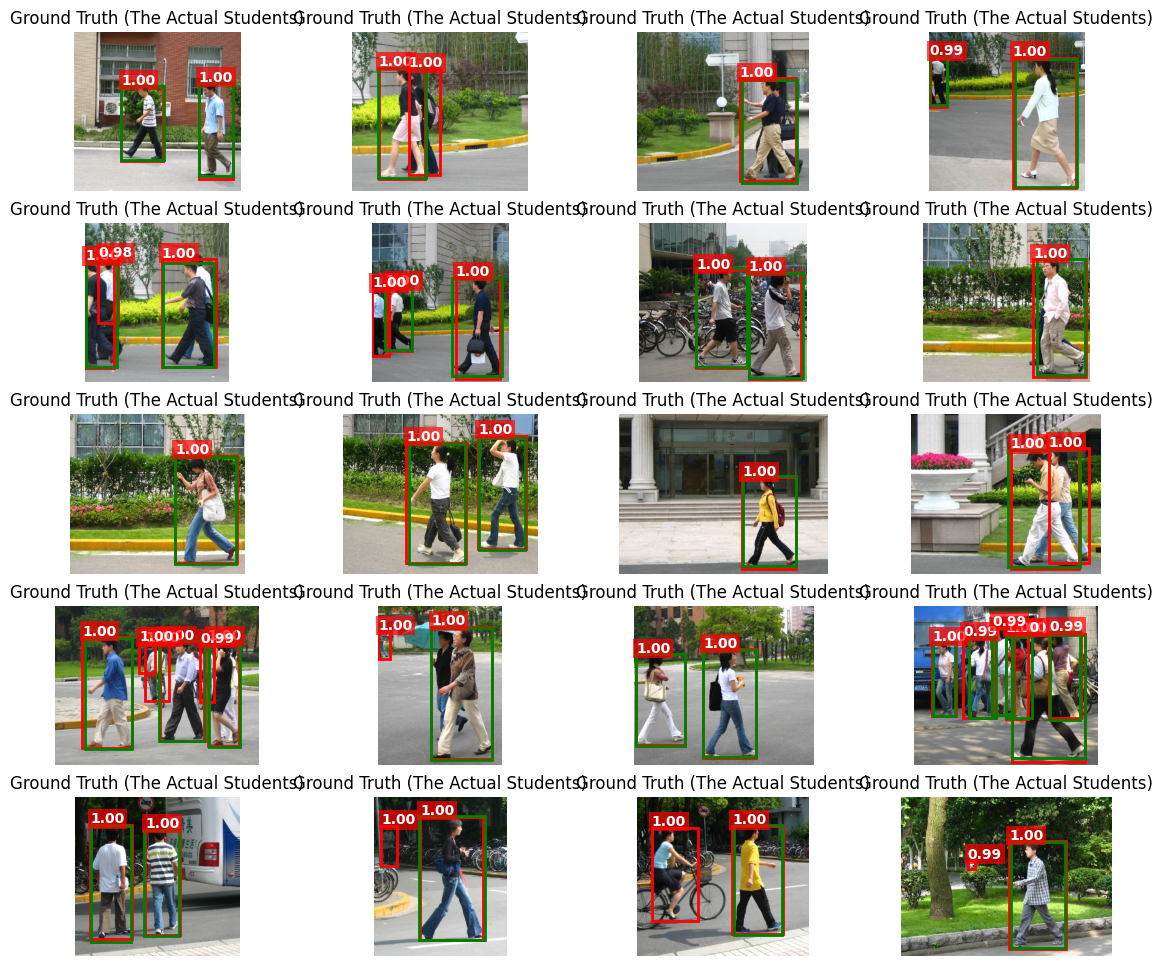

In [82]:
n=20
index=0

fig, ax = plt.subplots(5, 4, figsize=(14, 12))
ax = ax.flatten()

with open(TRAIN_CSV, "r", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        if index < n:
            img_path = os.path.join("train_data\\train", "images", row["filename"])
            pred_boxes_list = json.loads(row["pred_boxes"])
            pred_scores_list = json.loads(row["pred_scores"])
            gt_boxes_list = json.loads(row["gt_boxes"])
            clean_boxes, clean_scores = clean(pred_boxes_list, pred_scores_list, best_params[0], best_params[1])
            visualize_boxes(img_path, clean_boxes, ax[index], scores=clean_scores, color='red', title="Clean")

            visualize_boxes(img_path, gt_boxes_list, ax[index], color='green', title="Ground Truth (The Actual Students)")
            index+=1